In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
Data=pd.read_excel("ABC Company.xlsx")

In [4]:
Data.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0


# DATA PREPROCESSING

In [5]:
Data["Height"]=np.random.randint(150,181,size=len(Data))

In [6]:
Data.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,151,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,171,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,177,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,157,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,173,231,NaN,5000000.0


# ANALYSIS TASK

In [7]:
Count=Data["Team"].value_counts()
DF=pd.DataFrame(Count)
DF["Percentage"]=Count/len(Data)*100
print(DF)


                        count  Percentage
Team                                     
New Orleans Pelicans       19    4.148472
Memphis Grizzlies          18    3.930131
Utah Jazz                  16    3.493450
New York Knicks            16    3.493450
Milwaukee Bucks            16    3.493450
Brooklyn Nets              15    3.275109
Portland Trail Blazers     15    3.275109
Oklahoma City Thunder      15    3.275109
Denver Nuggets             15    3.275109
Washington Wizards         15    3.275109
Miami Heat                 15    3.275109
Charlotte Hornets          15    3.275109
Atlanta Hawks              15    3.275109
San Antonio Spurs          15    3.275109
Houston Rockets            15    3.275109
Boston Celtics             15    3.275109
Indiana Pacers             15    3.275109
Detroit Pistons            15    3.275109
Cleveland Cavaliers        15    3.275109
Chicago Bulls              15    3.275109
Sacramento Kings           15    3.275109
Phoenix Suns               15    3

In [8]:
Position=pd.DataFrame(Data["Position"].value_counts())
print(Position)

          count
Position       
SG          102
PF          100
PG           92
SF           85
C            79


In [36]:
Age_Group=[10,20,30,40,50]
Age_labels=["10-20","20-30","30-40","40-50"]
Data["Age_Details"]=pd.cut(Data["Age"],bins=Age_Group,labels=Age_labels)
print(Data["Age_Details"].value_counts())

Age_Details
20-30    346
30-40     91
10-20     21
40-50      0
Name: count, dtype: int64


In [10]:
position_salary=Data.groupby("Position")["Salary"].sum()
print(position_salary)

Position
C     466377332.0
PF    442560850.0
PG    446848971.0
SF    408020976.0
SG    396976258.0
Name: Salary, dtype: float64


In [11]:
Team_salary=Data.groupby("Team")["Salary"].sum()
print(Team_salary)

Team
Atlanta Hawks              72902950.0
Boston Celtics             58541068.0
Brooklyn Nets              52528475.0
Charlotte Hornets          78340920.0
Chicago Bulls              86783378.0
Cleveland Cavaliers       106988689.0
Dallas Mavericks           71198732.0
Denver Nuggets             60121930.0
Detroit Pistons            67168263.0
Golden State Warriors      88868997.0
Houston Rockets            75283021.0
Indiana Pacers             66751826.0
Los Angeles Clippers       94854640.0
Los Angeles Lakers         71770431.0
Memphis Grizzlies          76550880.0
Miami Heat                 82515673.0
Milwaukee Bucks            69603517.0
Minnesota Timberwolves     59709697.0
New Orleans Pelicans       82750774.0
New York Knicks            73303898.0
Oklahoma City Thunder      93765298.0
Orlando Magic              60161470.0
Philadelphia 76ers         30992894.0
Phoenix Suns               63445135.0
Portland Trail Blazers     48301818.0
Sacramento Kings           71683666.0
San Ant

11


<Axes: >

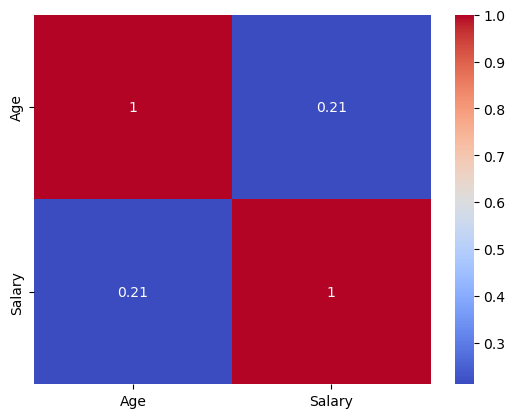

In [12]:
import seaborn as sns
print(Data["Salary"].isnull().sum())
Data["Salary"]=Data["Salary"].fillna(Data["Salary"].mean())
dfone=pd.DataFrame(Data[["Age","Salary"]].dropna())
correlation=dfone.corr()
sns.heatmap(correlation,annot=True,cmap="coolwarm")


# GRAPHICAL REPRESNETATION

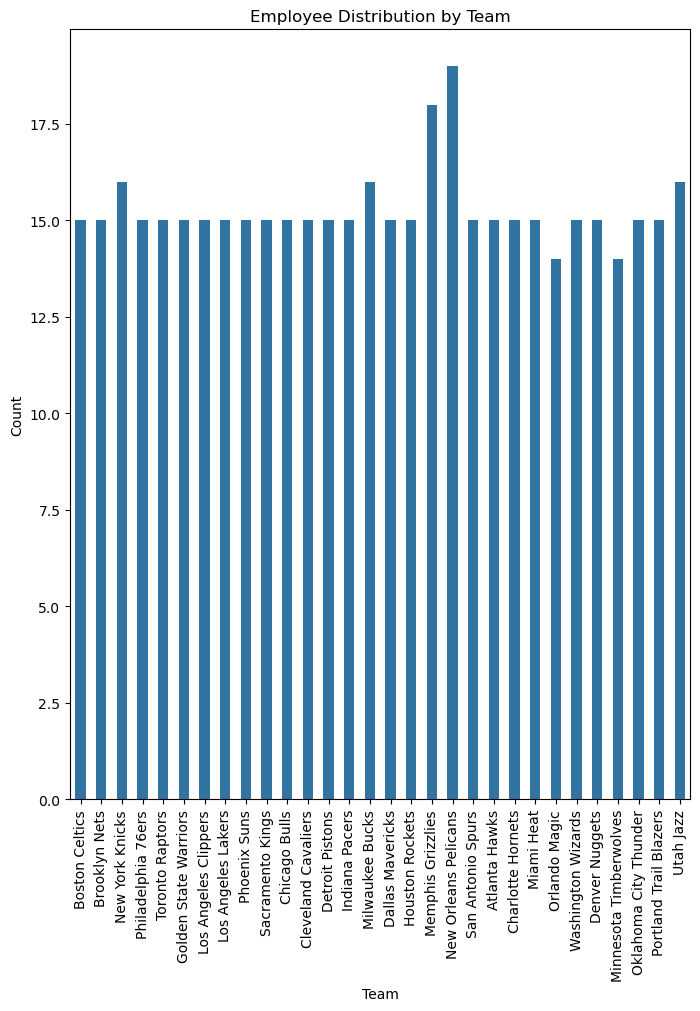

In [35]:
plt.figure(figsize=(8,10))

sns.countplot(x="Team",data=Data,width=0.5)

plt.title("Employee Distribution by Team")
plt.xlabel("Team")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

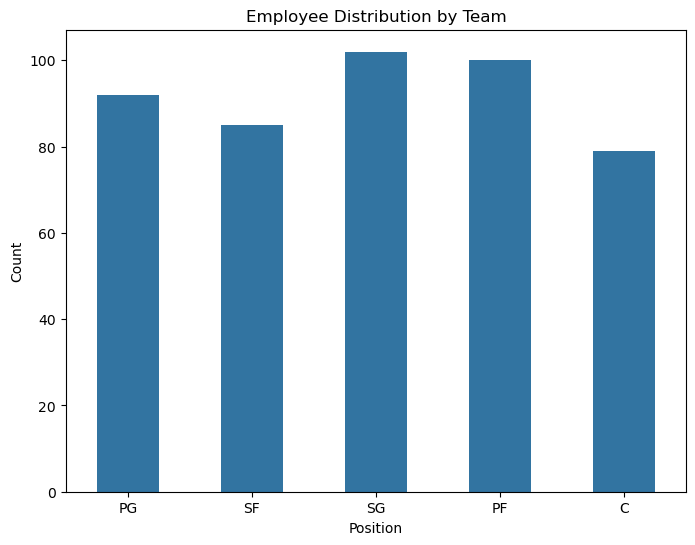

In [43]:
plt.figure(figsize=(8,6))

sns.countplot(x="Position",data=Data,width=0.5)

plt.title("Employee Distribution by Team")
plt.xlabel("Position")
plt.ylabel("Count")

plt.show()

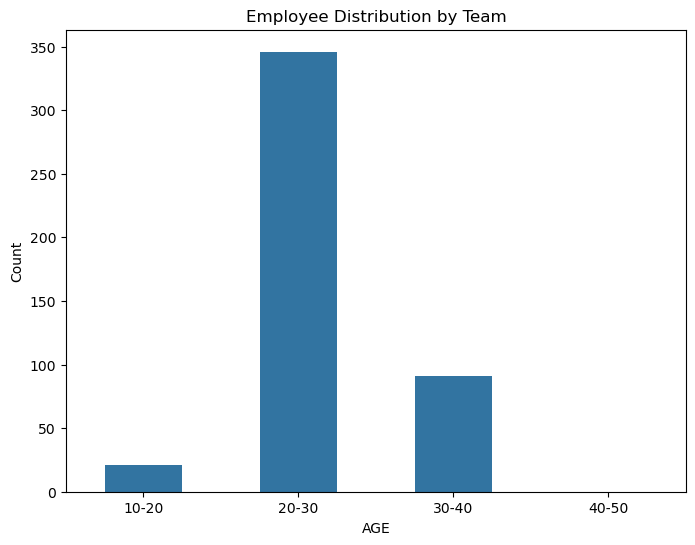

In [46]:
plt.figure(figsize=(8,6))

sns.countplot(x="Age_Details",data=Data,width=0.5)

plt.title("Employee Distribution by Team")
plt.xlabel("AGE")
plt.ylabel("Count")
plt.show()

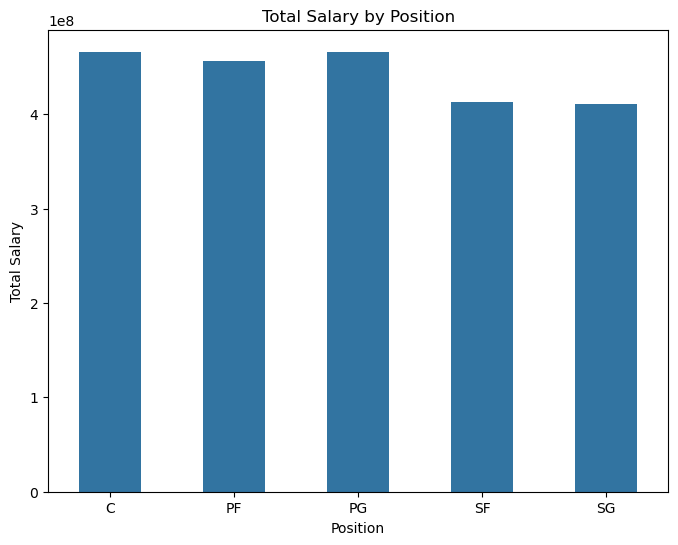

In [50]:
plt.figure(figsize=(8,6))

position_salary = Data.groupby("Position")["Salary"].sum()

sns.barplot(x=position_salary.index, y=position_salary.values, width=0.5)

plt.title("Total Salary by Position")
plt.xlabel("Position")
plt.ylabel("Total Salary")
plt.show()

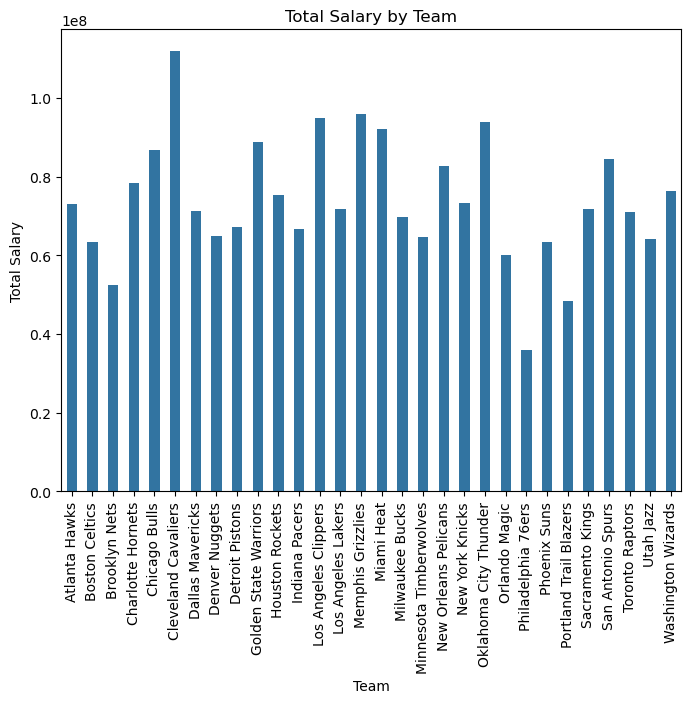

In [55]:
plt.figure(figsize=(8,6))
Team_salary=Data.groupby("Team")["Salary"].sum()
sns.barplot(x=Team_salary.index, y=Team_salary.values, width=0.5)
plt.title("Total Salary by Team")
plt.xlabel("Team")
plt.ylabel("Total Salary")
plt.xticks(rotation=90)
plt.show()

# Data Story

In [60]:
print("The analysis shows that some teams have more employees than others.Certain job positions are more common in the company.Most employees belong to a particular age group, showing a similar level of experience. Salary spending is higher in some teams and positions compared to others.Overall, the data shows clear patterns in employee distribution, age, and salary within the company.")

The analysis shows that some teams have more employees than others.Certain job positions are more common in the company.Most employees belong to a particular age group, showing a similar level of experience. Salary spending is higher in some teams and positions compared to others.Overall, the data shows clear patterns in employee distribution, age, and salary within the company.
